In [1]:
import pandas as pd
import yfinance as yf

tickers = [
    "NTPC.NS", "TATAPOWER.NS", "ADANIGREEN.NS", "ADANIENSOL.NS",
    "TORNTPOWER.NS", "CESC.NS", "JSWENERGY.NS", "POWERGRID.NS",
    "NHPC.NS", "SJVN.NS", "RECLTD.NS", "PFC.NS",
    "RPOWER.NS", "NAVA.NS", "ADANIPOWER.NS", "GIPCL.NS"
]

raw_data = yf.download(tickers, start="2020-01-01", end="2024-01-01")

print(raw_data.shape)
print(raw_data.head())

[*********************100%***********************]  16 of 16 completed

(992, 80)
Price              Close                                                    \
Ticker     ADANIENSOL.NS ADANIGREEN.NS ADANIPOWER.NS    CESC.NS   GIPCL.NS   
Date                                                                         
2020-01-01           NaN    174.750000         12.78  55.337612  61.024590   
2020-01-02           NaN    183.449997         12.89  55.941521  61.916397   
2020-01-03           NaN    192.600006         12.65  54.993046  67.394592   
2020-01-06           NaN    200.600006         12.02  53.970470  64.379463   
2020-01-07           NaN    210.600006         12.20  53.833393  65.313728   

Price                                                                ...  \
Ticker     JSWENERGY.NS    NAVA.NS    NHPC.NS    NTPC.NS     PFC.NS  ...   
Date                                                                 ...   
2020-01-01    65.502434  32.445522  17.863493  94.731239  59.837364  ...   
2020-01-02    65.929314  34.864517  17.863493  94.614357  60.

In [2]:
# Extract closing prices only
close_prices = raw_data['Close']

# Check for missing values
print("Missing values per company:")
print(close_prices.isnull().sum())

# Save to data folder
close_prices.to_csv("../data/power_sector_close_prices.csv")

print("\nFile saved successfully!")
print(close_prices.shape)

Missing values per company:
Ticker
ADANIENSOL.NS    900
ADANIGREEN.NS      0
ADANIPOWER.NS      0
CESC.NS            0
GIPCL.NS           0
JSWENERGY.NS       0
NAVA.NS            0
NHPC.NS            0
NTPC.NS            0
PFC.NS             0
POWERGRID.NS       0
RECLTD.NS          0
RPOWER.NS          0
SJVN.NS            0
TATAPOWER.NS       0
TORNTPOWER.NS      0
dtype: int64

File saved successfully!
(992, 16)


In [5]:
# Drop ADANIENSOL due to insufficient history
close_prices = close_prices.drop(columns=['ADANIENSOL.NS'])

# Verify no missing values remain
print("Missing values after dropping:")
print(close_prices.isnull().sum())

print(f"\nFinal dataset: {close_prices.shape}")
print(f"Companies: {close_prices.shape[1]}")
print(f"Trading days: {close_prices.shape[0]}")

# Save clean version
close_prices.to_csv("../data/power_sector_close_prices.csv")
print("\nClean file saved!")

Missing values after dropping:
Ticker
ADANIGREEN.NS    0
ADANIPOWER.NS    0
CESC.NS          0
GIPCL.NS         0
JSWENERGY.NS     0
NAVA.NS          0
NHPC.NS          0
NTPC.NS          0
PFC.NS           0
POWERGRID.NS     0
RECLTD.NS        0
RPOWER.NS        0
SJVN.NS          0
TATAPOWER.NS     0
TORNTPOWER.NS    0
dtype: int64

Final dataset: (992, 15)
Companies: 15
Trading days: 992

Clean file saved!


In [6]:
# Calculate daily percentage returns
daily_returns = close_prices.pct_change()

# Drop first row (NaN due to pct_change)
daily_returns = daily_returns.dropna()

# Quick summary
print("Daily Returns Summary:")
print(daily_returns.describe().round(4))

# Save returns
daily_returns.to_csv("../data/power_sector_daily_returns.csv")
print("\nReturns file saved!")

Daily Returns Summary:
Ticker  ADANIGREEN.NS  ADANIPOWER.NS   CESC.NS  GIPCL.NS  JSWENERGY.NS  \
count        991.0000       991.0000  991.0000  991.0000      991.0000   
mean           0.0028         0.0028    0.0010    0.0013        0.0023   
std            0.0341         0.0367    0.0209    0.0248        0.0304   
min           -0.2000        -0.2646   -0.1216   -0.1438       -0.1050   
25%           -0.0149        -0.0164   -0.0102   -0.0109       -0.0161   
50%            0.0015        -0.0004    0.0000    0.0000       -0.0023   
75%            0.0212         0.0193    0.0108    0.0108        0.0183   
max            0.2000         0.2000    0.1290    0.1995        0.1602   

Ticker   NAVA.NS   NHPC.NS   NTPC.NS    PFC.NS  POWERGRID.NS  RECLTD.NS  \
count   991.0000  991.0000  991.0000  991.0000      991.0000   991.0000   
mean      0.0025    0.0015    0.0013    0.0020        0.0012     0.0020   
std       0.0350    0.0221    0.0182    0.0232        0.0177     0.0225   
min      -

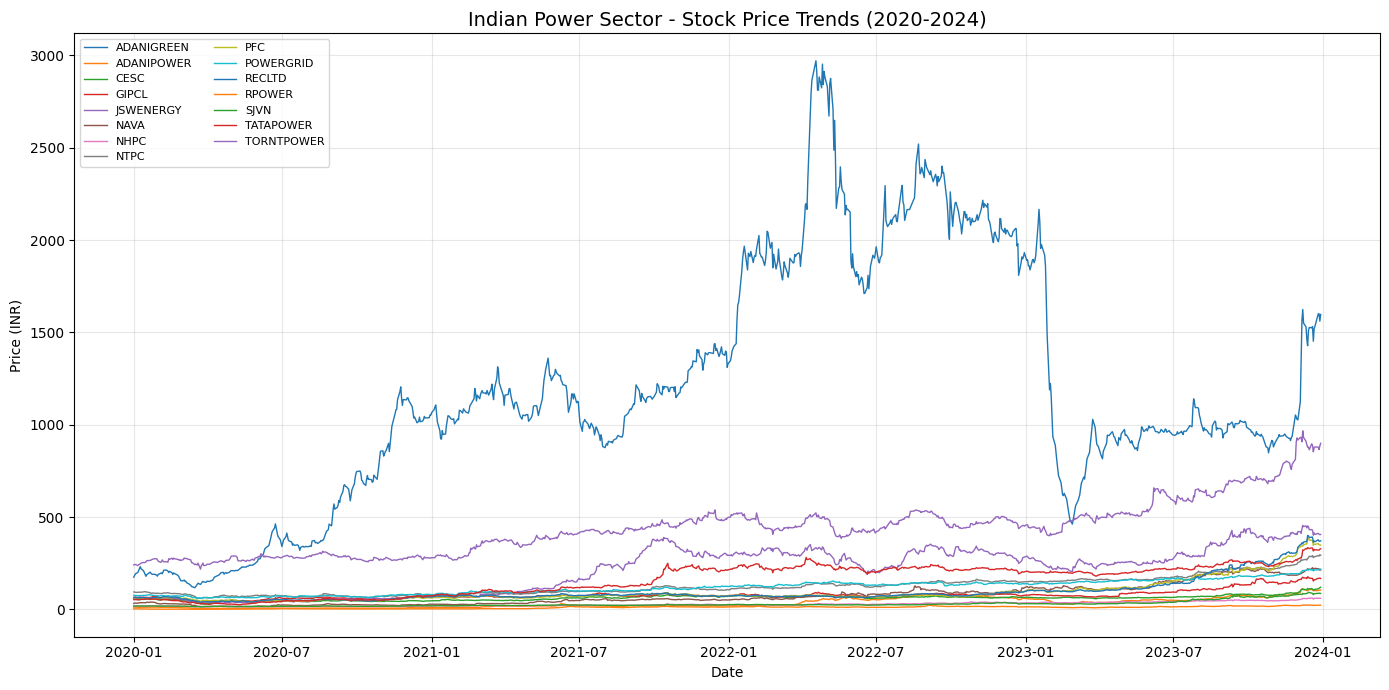

Chart saved!


In [7]:
import matplotlib.pyplot as plt

# Plot price trends
fig, ax = plt.subplots(figsize=(14, 7))

for column in close_prices.columns:
    ax.plot(close_prices.index, close_prices[column], label=column.replace('.NS', ''), linewidth=1)

ax.set_title('Indian Power Sector - Stock Price Trends (2020-2024)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price (INR)')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/price_trends.png', dpi=150)
plt.show()

print("Chart saved!")

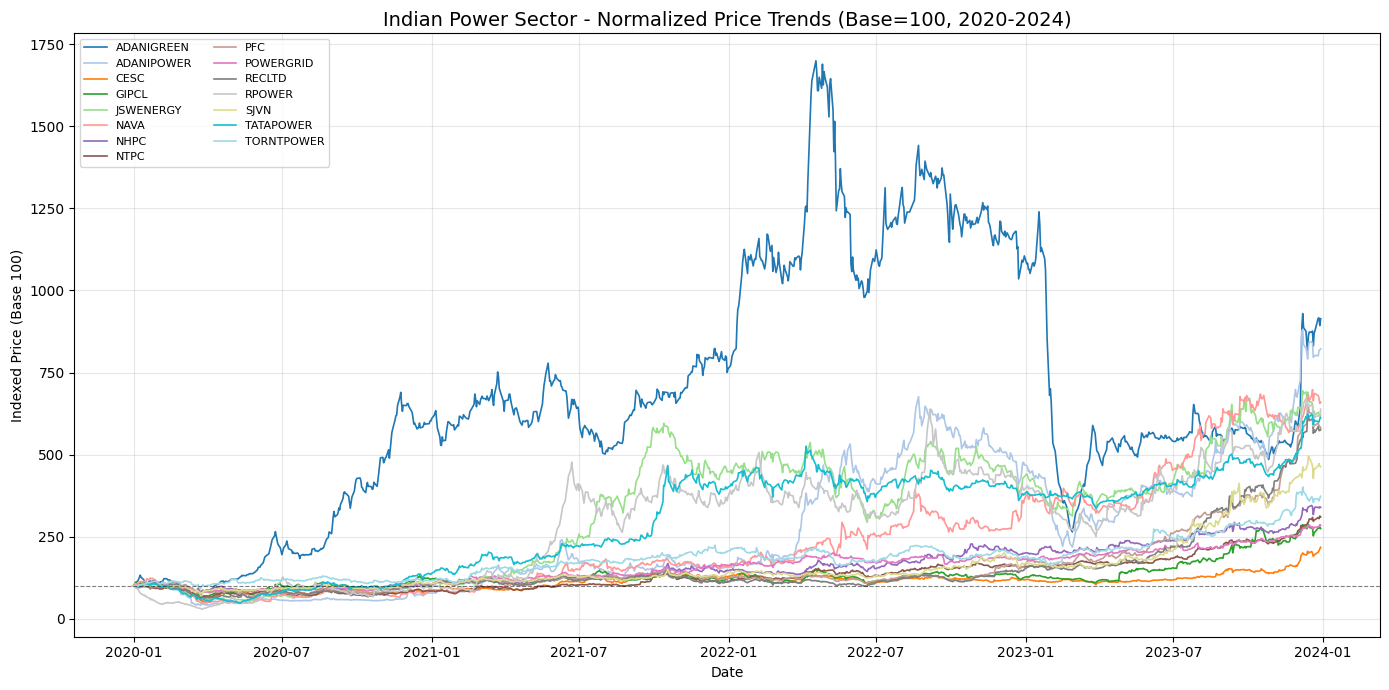

In [8]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Generate distinct colors
colors = cm.tab20(np.linspace(0, 1, len(close_prices.columns)))

# Normalize prices to 100 (base indexing)
# This makes comparison fair regardless of stock price
normalized = (close_prices / close_prices.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(14, 7))

for i, column in enumerate(normalized.columns):
    ax.plot(normalized.index, 
            normalized[column], 
            label=column.replace('.NS', ''), 
            linewidth=1.2,
            color=colors[i])

ax.set_title('Indian Power Sector - Normalized Price Trends (Base=100, 2020-2024)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Indexed Price (Base 100)')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
ax.axhline(y=100, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../data/normalized_price_trends.png', dpi=150)
plt.show()

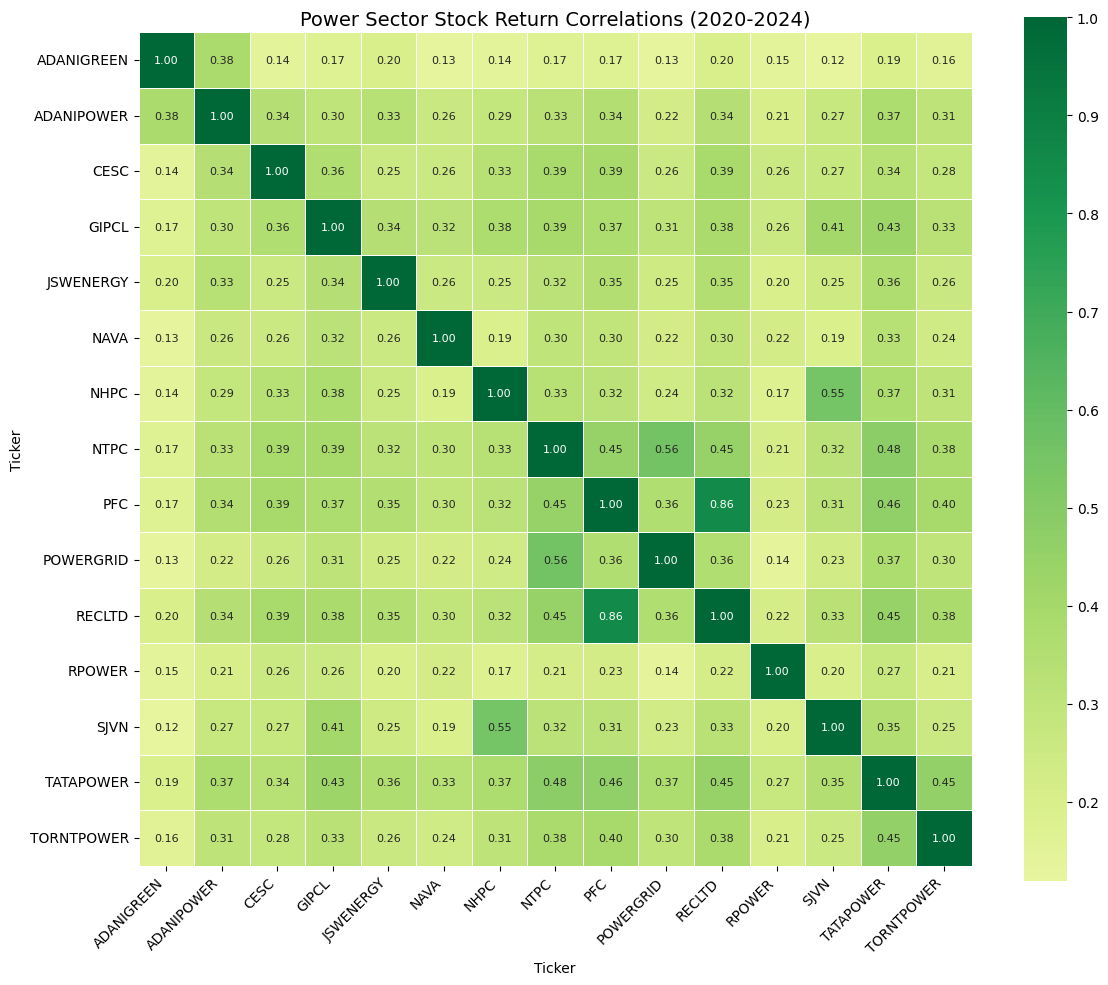

In [9]:
import seaborn as sns

# Calculate correlation matrix
correlation = daily_returns.corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(correlation, 
            annot=True, 
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5,
            annot_kws={"size": 8},
            xticklabels=[x.replace('.NS','') for x in correlation.columns],
            yticklabels=[x.replace('.NS','') for x in correlation.index],
            ax=ax)

ax.set_title('Power Sector Stock Return Correlations (2020-2024)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../data/correlation_heatmap.png', dpi=150)
plt.show()

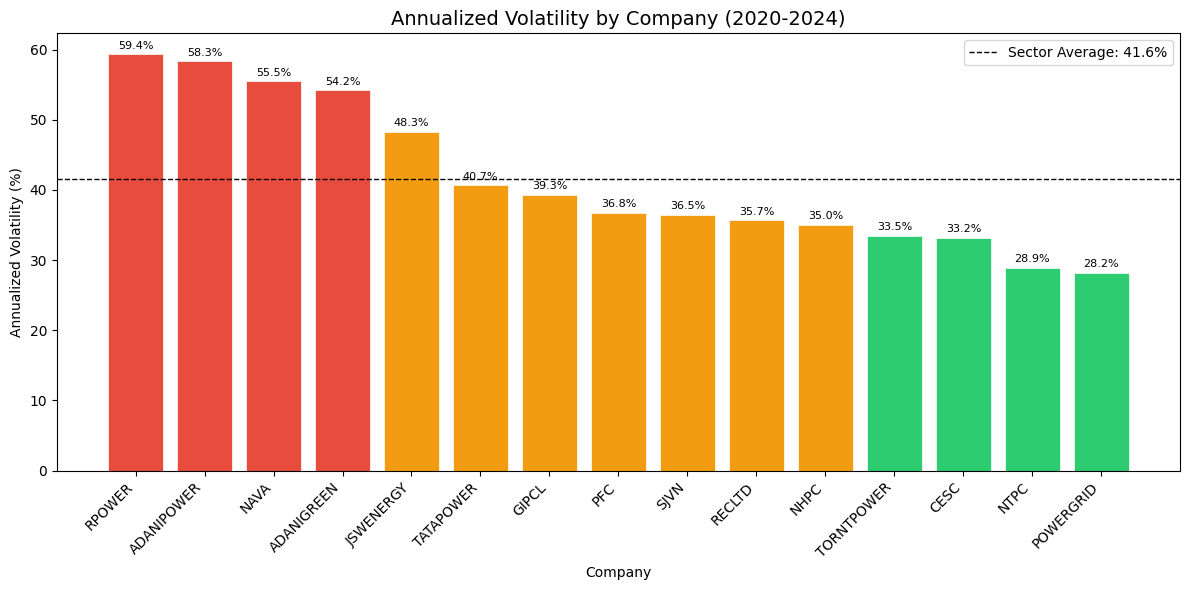


Volatility Rankings:
Ticker
RPOWER.NS        59.35
ADANIPOWER.NS    58.32
NAVA.NS          55.52
ADANIGREEN.NS    54.21
JSWENERGY.NS     48.27
TATAPOWER.NS     40.66
GIPCL.NS         39.31
PFC.NS           36.75
SJVN.NS          36.48
RECLTD.NS        35.67
NHPC.NS          35.05
TORNTPOWER.NS    33.50
CESC.NS          33.18
NTPC.NS          28.89
POWERGRID.NS     28.17
Name: Annual Volatility %, dtype: float64


In [10]:
# Annualized volatility for each company
volatility = daily_returns.std() * (252 ** 0.5) * 100

volatility = volatility.sort_values(ascending=False)
volatility.name = 'Annual Volatility %'

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#e74c3c' if v > 50 else '#f39c12' if v > 35 else '#2ecc71' 
          for v in volatility.values]

bars = ax.bar(volatility.index.str.replace('.NS',''), 
              volatility.values, 
              color=colors,
              edgecolor='white',
              linewidth=0.5)

ax.set_title('Annualized Volatility by Company (2020-2024)', fontsize=14)
ax.set_xlabel('Company')
ax.set_ylabel('Annualized Volatility (%)')
ax.axhline(y=volatility.mean(), color='black', linestyle='--', 
           linewidth=1, label=f'Sector Average: {volatility.mean():.1f}%')
ax.legend()
plt.xticks(rotation=45, ha='right')

for bar, val in zip(bars, volatility.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../data/volatility_comparison.png', dpi=150)
plt.show()

print("\nVolatility Rankings:")
print(volatility.round(2))

In [11]:
ratios_data = []

for stock in close_prices.columns:
    ticker = yf.Ticker(stock)
    info = ticker.info
    
    ratios_data.append({
        "Stock": stock.replace(".NS",""),
        "DebtToEquity": info.get("debtToEquity"),
        "ROE": info.get("returnOnEquity"),
        "CurrentRatio": info.get("currentRatio")
    })

df_ratios = pd.DataFrame(ratios_data)
df_ratios

,Stock,DebtToEquity,ROE,CurrentRatio
0,ADANIGREEN,296.223,NaN,None
1,ADANIPOWER,81.251,NaN,None
2,CESC,141.107,NaN,None
3,GIPCL,79.265,NaN,None
4,JSWENERGY,218.668,NaN,None
5,NAVA,15.987,NaN,None
6,NHPC,100.410,NaN,None
7,NTPC,118.127,NaN,None
8,PFC,603.342,NaN,None
9,POWERGRID,141.186,NaN,None


In [12]:
df_ratios = df_ratios.fillna(0).infer_objects(copy=False)

C:\Users\BABLU\AppData\Local\Temp\ipykernel_17280\1753854417.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_ratios = df_ratios.fillna(0).infer_objects(copy=False)


In [13]:
def risk_score(row):
    score = 0

    # Debt to Equity (MAIN factor now)
    if row["DebtToEquity"] < 100:
        score += 2
    elif row["DebtToEquity"] < 300:
        score += 1

    # ROE (only if available)
    if row["ROE"] > 0.15:
        score += 2

    # Current Ratio (only if available)
    if row["CurrentRatio"] > 1:
        score += 1

    return score

In [14]:
df_ratios["RiskScore"] = df_ratios.apply(risk_score, axis=1)

In [15]:
def classify(score):
    if score >= 4:
        return "Low Risk"
    elif score >= 2:
        return "Medium Risk"
    else:
        return "High Risk"

df_ratios["RiskCategory"] = df_ratios["RiskScore"].apply(classify)

In [16]:
# Calculate cumulative max (peak)
rolling_max = close_prices.cummax()

# Calculate drawdown
drawdown = (close_prices - rolling_max) / rolling_max

In [17]:
max_drawdown = drawdown.min().sort_values()

max_drawdown.name = "Max Drawdown"
print(max_drawdown)

Ticker
ADANIGREEN.NS   -0.844403
RPOWER.NS       -0.712329
ADANIPOWER.NS   -0.677803
NAVA.NS         -0.622611
TATAPOWER.NS    -0.556458
JSWENERGY.NS    -0.506295
CESC.NS         -0.494817
GIPCL.NS        -0.456432
RECLTD.NS       -0.436318
PFC.NS          -0.387515
NTPC.NS         -0.383125
NHPC.NS         -0.309393
TORNTPOWER.NS   -0.286158
SJVN.NS         -0.269717
POWERGRID.NS    -0.269703
Name: Max Drawdown, dtype: float64


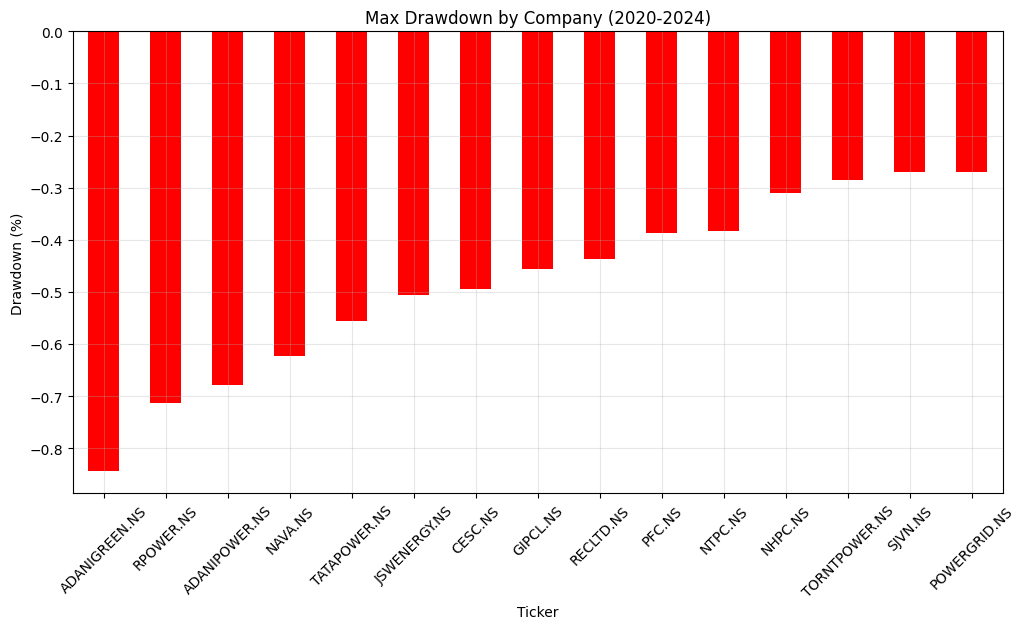

In [44]:
plt.figure(figsize=(12,6))

max_drawdown.plot(kind='bar', color='red')

plt.title("Max Drawdown by Company (2020-2024)")
plt.ylabel("Drawdown (%)")
plt.xticks(rotation=45)

plt.grid(alpha=0.3)
plt.savefig('../data/max_drawdown_by_company.png', dpi=150)
plt.show()

In [19]:
rolling_vol = daily_returns.rolling(window=20).std() * (252 ** 0.5)

<Figure size 1200x600 with 0 Axes>

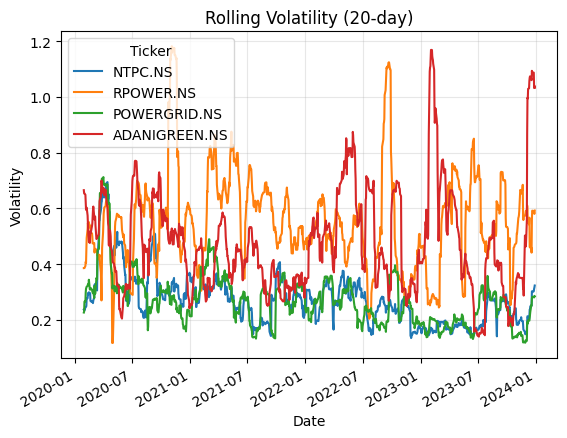

In [45]:
plt.figure(figsize=(12,6))

rolling_vol[['NTPC.NS','RPOWER.NS','POWERGRID.NS','ADANIGREEN.NS']].plot()

plt.title("Rolling Volatility (20-day)")
plt.ylabel("Volatility")
plt.grid(alpha=0.3)
plt.savefig('../data/rolling_volatility_20day.png', dpi=150)
plt.show()

In [21]:
num_stocks = len(daily_returns.columns)

weights = np.array([1/num_stocks] * num_stocks)

In [22]:
portfolio_returns = daily_returns.dot(weights)

print(portfolio_returns.head())

Date
2020-01-02    0.011441
2020-01-03    0.002054
2020-01-06   -0.020460
2020-01-07    0.014751
2020-01-08   -0.004164
dtype: float64


In [23]:
portfolio_return = portfolio_returns.mean() * 252

In [24]:
portfolio_volatility = portfolio_returns.std() * (252 ** 0.5)

In [25]:
print(f"Annual Return: {portfolio_return:.2%}")
print(f"Annual Volatility: {portfolio_volatility:.2%}")

Annual Return: 48.52%
Annual Volatility: 24.14%


In [26]:
risk_free_rate = 0.05  # assume 5%

sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility

print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

Sharpe Ratio: 1.80


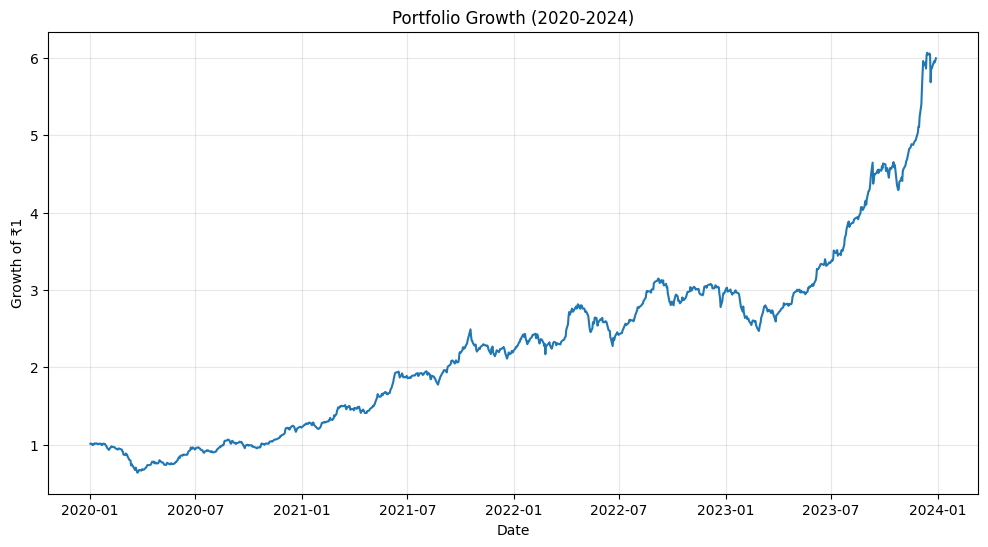

In [46]:
cumulative_returns = (1 + portfolio_returns).cumprod()

plt.figure(figsize=(12,6))
plt.plot(cumulative_returns)

plt.title("Portfolio Growth (2020-2024)")
plt.xlabel("Date")
plt.ylabel("Growth of ₹1")
plt.grid(alpha=0.3)
plt.savefig('../data/portfolio_growth.png', dpi=150)
plt.show()

In [28]:
stock = "RPOWER.NS"
price = close_prices[stock]

In [29]:
ma20 = price.rolling(window=20).mean()
ma50 = price.rolling(window=50).mean()

In [30]:
signals = pd.DataFrame(index=price.index)

signals['price'] = price
signals['MA20'] = ma20
signals['MA50'] = ma50

signals['Signal'] = 0
signals.loc[signals['MA20'] > signals['MA50'], 'Signal'] = 1

signals['Position'] = signals['Signal'].diff()

In [31]:
stock_returns = price.pct_change()

strategy_returns = stock_returns * signals['Signal'].shift(1)

strategy_returns = strategy_returns.dropna()

In [32]:
cumulative_strategy = (1 + strategy_returns).cumprod()
cumulative_market = (1 + stock_returns).cumprod()

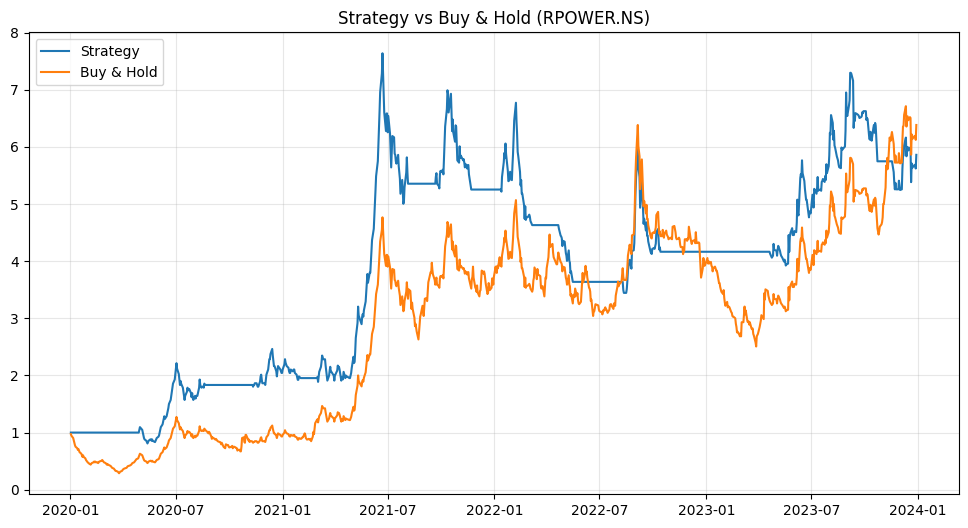

In [47]:
plt.figure(figsize=(12,6))

plt.plot(cumulative_strategy, label="Strategy")
plt.plot(cumulative_market, label="Buy & Hold")

plt.title(f"Strategy vs Buy & Hold ({stock})")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('../data/trading_strategy_BuyHold.png', dpi=150)
plt.show()

In [34]:
strategy_return = strategy_returns.mean() * 252
strategy_vol = strategy_returns.std() * (252 ** 0.5)

print(f"Strategy Return: {strategy_return:.2%}")
print(f"Strategy Volatility: {strategy_vol:.2%}")

Strategy Return: 54.88%
Strategy Volatility: 44.75%


VALUE AT RISK (VaR)
VaR=μ−z⋅σ

In [36]:
confidence_level = 0.95
z = 1.65

var = portfolio_return - z * portfolio_volatility

print(f"Value at Risk (95%): {var:.2%}")

Value at Risk (95%): 8.68%


In [37]:
if var < 0:
    print("There is a 5% chance of losing more than this value in a year.")
else:
    print("Portfolio shows relatively low downside risk.")

Portfolio shows relatively low downside risk.


“The Value at Risk (VaR) at 95% confidence level indicates the maximum expected loss under normal market conditions. This means there is a 5% probability that the portfolio may incur losses greater than the calculated VaR.”

In [38]:
print("Portfolio Return:", portfolio_return)
print("Portfolio Volatility:", portfolio_volatility)
print("VaR:", var)

Portfolio Return: 0.48515705394460856
Portfolio Volatility: 0.241436672311409
VaR: 0.08678654463078372


In [39]:
historical_var = portfolio_returns.quantile(0.05)

print(f"Historical VaR: {historical_var:.2%}")

Historical VaR: -2.20%


COMPARISON ANALYSIS (NTPC vs RPOWER vs PORTFOLIO)

We’ll compare:

Stable stock → NTPC
Risky stock → RPOWER
Our portfolio

In [40]:
stock_safe = "NTPC.NS"
stock_risky = "RPOWER.NS"

returns_safe = daily_returns[stock_safe]
returns_risky = daily_returns[stock_risky]

In [41]:
# Annual Return
safe_return = returns_safe.mean() * 252
risky_return = returns_risky.mean() * 252

# Volatility
safe_vol = returns_safe.std() * (252 ** 0.5)
risky_vol = returns_risky.std() * (252 ** 0.5)

# Sharpe Ratio (assume 5%)
rf = 0.05

safe_sharpe = (safe_return - rf) / safe_vol
risky_sharpe = (risky_return - rf) / risky_vol
portfolio_sharpe = (portfolio_return - rf) / portfolio_volatility

In [42]:
import pandas as pd

comparison = pd.DataFrame({
    "Asset": ["NTPC", "RPOWER", "Portfolio"],
    "Return": [safe_return, risky_return, portfolio_return],
    "Volatility": [safe_vol, risky_vol, portfolio_volatility],
    "Sharpe Ratio": [safe_sharpe, risky_sharpe, portfolio_sharpe]
})

print(comparison)

       Asset    Return  Volatility  Sharpe Ratio
0       NTPC  0.329541    0.288875      0.967688
1     RPOWER  0.644897    0.593524      1.002313
2  Portfolio  0.485157    0.241437      1.802365


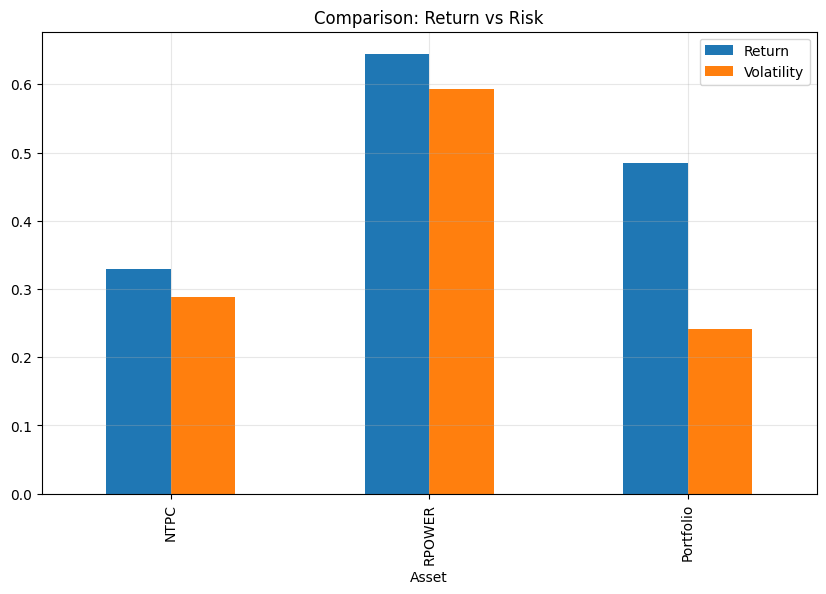

In [48]:
comparison.set_index("Asset")[["Return", "Volatility"]].plot(kind="bar", figsize=(10,6))
plt.title("Comparison: Return vs Risk")
plt.grid(alpha=0.3)
plt.savefig('../data/comparisonBar_risk_volatility.png', dpi=150)
plt.show()